# End-to-end bi-rads classification model built in Pytorch.

**Use case :** Vindr-Mammo. <br />
**Model used :** VGG11. <br />

The goal of this notebook is to provide a better understanding of how to work with Pytorch to train neural networks. <br />
Our use case aims to classify patches drawn from the Vindr-Mammo dataset using the bi-rads assessment system.

We assume a Python environment is set with all required dependencies.
If it is not, this notebook was ran using Python 3.12 with the following dependencies : 

- torch
- torchvision
- pandas
- pydicom
- numpy
- opencv-python
- matplotlib
- Pillow
- torchsummary

In [57]:
import torch, os, torchvision, ast, cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torchsummary import summary
from torch import nn
from torch.utils.data import Dataset, DataLoader
from pydicom import dcmread
from pydicom.pixels import apply_voi_lut
from PIL import Image
from tqdm import tqdm

The next block defines global variables used in the project, paths should be changed.

In [3]:
vindr_path = '/Volumes/T7_KAPTIOS/datasets/Vindr/original/'

## 1. Building / Using a dataset

This is the first step of any ML project. Pytorch comes with supports for open-source pre-build benchmark datasets like MNIST, CIFAR10 or FashionMNIST. These datasets are all extended from the ```torch.utils.data.Dataset``` class that defines a basic iterable Dataset. To train our model on the Vindr-Mammo, we first need to define a pre-processing pipeline to load the data according to our classification needs.

### 1.1. Data pre-processing

To prepare the data, we apply the following pipeline : 

- 1. Load and clean the finding_annotations.csv file
- 2. Convert Dicom to Numpy Arrays
- 3. Extract patches using the bounding boxes coordinates
- 4. Normalize the patches

For simplicity, the first step will also filter the dataset to only keep scans where a ```mass``` or a ```suspicious_calcification``` was found.

#### 1.1.1. Load and clean the finding_annotations.csv file

The following block of functions are used to prepare a Dataframe from the ```finding_annotations.csv``` file. They standardize string values and names, and rename bi-rads assessment to use the 3 classes bi-rads system.

In [4]:
def format_char(char):
        return char.lower().replace(' ', '_')

def format_category_list(category_list):
    return [format_char(category) for category in category_list]

def contains_all_classes(category_list, class_list):
    return any(cls in category_list for cls in class_list)

def replace_categories(df, column, target_categories):
    def replace_if_present(categories):
        for target in target_categories:
            if target in categories:
                return target
        return categories

    df[column] = df[column].apply(
        lambda x: replace_if_present(x) if isinstance(x, list) else x)
    return df 

def load_vindr_dataframe(data_dir: str, is_train: bool = True, class_list: list = ['mass', 'suspicious_calcification'] ):
    """Reads and clean the finding_annotations.csv from Vindr Mammo, filter rows to keep chosen classes, cast bounding box values to int.

    Args:
        data_dir (str): The directory where the vindr-mammo dataset is saved.
        is_train (bool, optional): Whether to retrieve training split or not. Defaults to True.
        class_list (list, optional): The list of classes to KEEP. Defaults to ['mass', 'suspicious_calcification']

    Returns:
        pd.Dataframe: The cleaned Dataframe
    """

    birads_mapping = {
        'bi-rads_1': '0',
        'bi-rads_2': '1',
        'bi-rads_3': '2',
        'bi-rads_4': '2',
        'bi-rads_5': '2'
    }
    
    df_find = pd.read_csv(os.path.join(
        data_dir, 'finding_annotations.csv'))
    df_find['finding_categories'] = df_find['finding_categories'].apply(
        ast.literal_eval)
    df_find['finding_categories'] = df_find['finding_categories'].apply(
        format_category_list)
    df_find['breast_birads'] = df_find['breast_birads'].apply(
        format_char)
    df_find['breast_birads'] = df_find['breast_birads'].replace(
        birads_mapping)
    df_find.drop_duplicates(subset='image_id', keep=False, inplace=True)
    split_name = 'training' if is_train else 'test'
    df_find = df_find[df_find['split'] == split_name]

    df_find = df_find[df_find['finding_categories'].apply(lambda x: contains_all_classes(x, class_list))]
    replace_categories(df_find, 'finding_categories', class_list)
    df_find[['xmin', 'xmax', 'ymin', 'ymax']] = df_find[['xmin', 'xmax', 'ymin', 'ymax']].astype(int)
    return df_find

In [5]:
training_df = load_vindr_dataframe(vindr_path, True)
validation_df = load_vindr_dataframe(vindr_path, False)
training_df.head()

,study_id,series_id,image_id,laterality,view_position,height,width,breast_birads,breast_density,finding_categories,finding_birads,xmin,ymin,xmax,ymax,split
0,48575a27b7c992427041a82fa750d3fa,26de4993fa6b8ae50a91c8baf49b92b0,4e3a578fe535ea4f5258d3f7f4419db8,R,CC,3518,2800,2,DENSITY C,mass,BI-RADS 4,2355,1731,2482,1852,training
1,48575a27b7c992427041a82fa750d3fa,26de4993fa6b8ae50a91c8baf49b92b0,dac39351b0f3a8c670b7f8dc88029364,R,MLO,3518,2800,2,DENSITY C,mass,BI-RADS 4,2386,1240,2501,1354,training
8,7c51789da6c462e55bcb95c2a7d437ee,ac4d0771f6d7a7400ab463458f789dbe,f581ef53bb7e61f4575db33eceac8ff8,L,CC,3518,2800,2,DENSITY C,mass,BI-RADS 4,588,1397,812,1734,training
9,7c51789da6c462e55bcb95c2a7d437ee,ac4d0771f6d7a7400ab463458f789dbe,1142cdfbfe725d62038252693cf064e5,L,MLO,3518,2800,2,DENSITY C,mass,BI-RADS 4,632,1727,930,2190,training
10,89524e5f372d9aff8ed43b4ef29c1435,0838a0b906894e0cc06c993426a2d143,5a94dd668eaa9865b907450c37db6ecc,R,CC,3518,2800,2,DENSITY C,mass,BI-RADS 3,1988,1793,2139,1967,training


#### 1.1.2. Convert Dicom to Numpy Arrays

The next function can be used to read a dicom image and return a normalized array representation of it.

In [6]:
def read_dicom(path: str):
    """Read a dicom file and return its np.array representation;
    The method applies a VOI lookup table and invert pixels intensities when the PhotometricInterpretation of
    a file is found to be 'MONOCHROME1'.

    Args:
        path (str): Path to dicom file

    Returns:
        np.array: The loaded image as np.array
    """
    ds = dcmread(path)
    img2d = ds.pixel_array
    img2d = apply_voi_lut(img2d, ds)
    if ds.PhotometricInterpretation == "MONOCHROME1":
        img2d = np.amax(img2d) - img2d

    return img2d

We can take a sample from the prepared Dataframe and display the processed image.

Image path : /Volumes/T7_KAPTIOS/datasets/Vindr/original/images/48575a27b7c992427041a82fa750d3fa/4e3a578fe535ea4f5258d3f7f4419db8.dicom
Image size : (3518, 2800)


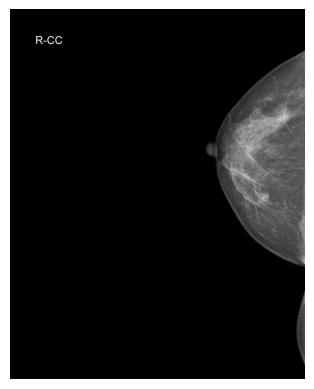

In [7]:
row = training_df.iloc[0]
sample_path = os.path.join(vindr_path, 'images', row['study_id'], row['image_id'] + '.dicom')
print(f'Image path : {sample_path}')

img = read_dicom(sample_path)
print(f'Image size : {img.shape}')

plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()

#### 1.1.3. Extract patches using the bounding boxes coordinates

To add some context, the bounding boxes will be retrieved with a padding.

In [8]:
def extract_bounding_box(image: np.ndarray, xmin: int, xmax: int, ymin: int, ymax: int, padding: int = 0) -> np.ndarray:
    """
    Extracts a bounding box from the given image based on the specified coordinates with optional padding.

    Parameters:
        image (np.ndarray): The input image as a NumPy array.
        xmin (int): Minimum x-coordinate of the bounding box.
        xmax (int): Maximum x-coordinate of the bounding box.
        ymin (int): Minimum y-coordinate of the bounding box.
        ymax (int): Maximum y-coordinate of the bounding box.
        padding (int, optional): Additional padding around the bounding box. Defaults to 0.

    Returns:
        np.ndarray: The cropped bounding box as a NumPy array.
    """
    # Apply padding
    xmin = max(0, xmin - padding)
    ymin = max(0, ymin - padding)
    xmax = min(image.shape[1], xmax + padding)
    ymax = min(image.shape[0], ymax + padding)
    
    return image[ymin:ymax, xmin:xmax]

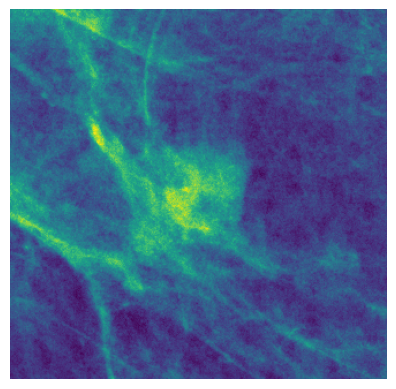

In [9]:
bbox = extract_bounding_box(img, row['xmin'], row['xmax'], row['ymin'], row['ymax'], 100)

plt.imshow(bbox)
plt.axis('off')
plt.show()

#### 1.1.4. Normalize the patches

In [10]:
def normalize_img(img):
    return cv2.normalize(
        img, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_32F
    ).astype(np.uint8)

img = normalize_img(img)

print(f'Minimum value : {img.min()} | Maximum value : {img.max()}')

Minimum value : 0 | Maximum value : 255


### 1.2. Create the Pytorch custom dataset

Now that the pre-processing functions are defined we can wrap everything up in a custom Pytorch Dataset.
In PyTorch, the Dataset class (torch.utils.data.Dataset) is an abstraction used to handle and manage data efficiently for training and evaluation. It provides a structured way to load, preprocess, and access data samples. By subclassing Dataset, users can define how data is stored and retrieved by implementing the ```__len__``` method (which returns the total number of samples) and the ```__getitem__``` method (which fetches a single data sample based on an index). This design makes it easy to work with large datasets, as data can be lazily loaded instead of being stored entirely in memory.

In [11]:
class VindrPatchDataset(Dataset):
    def __init__(self, data_dir, train = True, transform=None):
        self.data_dir = data_dir
        self.df = load_vindr_dataframe(data_dir, train)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        sample_path = os.path.join(self.data_dir, 'images', row['study_id'], row['image_id'] + '.dicom')
        image = read_dicom(sample_path)
        image = extract_bounding_box(image, row['xmin'], row['xmax'], row['ymin'], row['ymax'], 100)
        image = normalize_img(image)

        label = int(row['breast_birads'])

        if self.transform:
            image = self.transform(Image.fromarray(image))
            
        return image, label

Note that the Dataset as a ```transform``` parameter that is being used in the ```__getitem__``` method. In PyTorch, transforms (```torchvision.transforms```) are used to preprocess and augment data, particularly for images in computer vision tasks. They help convert raw data into a format suitable for training deep learning models. Transforms can be applied to tensors or PIL images, performing operations like normalization, resizing, cropping, flipping, and color adjustments. PyTorch provides a variety of built-in transforms, such as ```transforms.ToTensor()``` (converts an image to a tensor) and ```transforms.Normalize()``` (scales pixel values). Multiple transformations can be combined using ```transforms.Compose()```, ensuring that data is consistently processed before being fed into a model. Using transforms improves model generalization by enhancing data variability and ensuring input consistency.

For our use case, we only apply a ```Resize``` transform (to set input shape to 224x224 as VGG requires that size) and a ```ToTensor``` transform. The ```ToTensor``` will convert the Pillow Image to a Pytorch Tensor of shape (C, W, H) and normalized it in (0, 1) float.

In [63]:
tfs = torchvision.transforms.Compose([
    torchvision.transforms.transforms.Resize((224, 224)),
    torchvision.transforms.transforms.ToTensor(),
])

training_dataset = VindrPatchDataset(vindr_path, True, transform=tfs)
validation_dataset = VindrPatchDataset(vindr_path, False, transform=tfs)

Any sample from these datasets can now be accessed by the mean of an index, it should return a tuple of two items, the image and the label : 

In [41]:
sample = training_dataset[0]
print('Image : {}'.format(sample[0]))
print('Label : {}'.format(sample[1]))

Image : tensor([[[0.4980, 0.5176, 0.5490,  ..., 0.3098, 0.2627, 0.2745],
         [0.4980, 0.5137, 0.5490,  ..., 0.3412, 0.3137, 0.2510],
         [0.4784, 0.4745, 0.5333,  ..., 0.2863, 0.2902, 0.2275],
         ...,
         [0.0706, 0.0902, 0.1333,  ..., 0.3137, 0.3255, 0.3529],
         [0.1020, 0.1098, 0.1294,  ..., 0.3647, 0.3608, 0.3490],
         [0.1412, 0.1176, 0.1216,  ..., 0.3373, 0.3137, 0.3412]]])
Label : 2


## 2. Building dataloaders

A DataLoader (```torch.utils.data.DataLoader```) is used to efficiently load and manage data during training and evaluation. It acts as a wrapper around a Dataset, handling tasks such as batching, shuffling, and parallel data loading to improve performance. The DataLoader allows models to process data in mini-batches instead of loading the entire dataset into memory, making it essential for training on large datasets. Key parameters include ```batch_size``` (number of samples per batch), ```shuffle``` (randomizes data order for better generalization), and ```num_workers``` (enables parallel data loading for faster processing, depending on available processes).

We build dataloaders for both training and validation. Note that since Vindr-Mammo does not have three splits (training, validation and testing), the validation split will also be used for testing.

> Note : The validation set is used during the model's training phase to objectively assess its performance and adjust its parameters (gradient/loss computation). In contrast, the test set is employed after training is complete to evaluate how well the model performs on entirely new data.

In [42]:
training_dataloader = DataLoader(training_dataset, batch_size=8, shuffle=True)
validation_dataloader = DataLoader(validation_dataset, batch_size=8, shuffle=False)

Dataloaders being Iterators, a sample can be accessed like : 

In [43]:
sample = next(iter(training_dataloader))
print(f'Image batch size : {sample[0].shape}')
print(f'Label batch size : {sample[1].shape}')

Image batch size : torch.Size([8, 1, 224, 224])
Label batch size : torch.Size([8])


## 3. Creating a model

A model is typically defined as a subclass of ```torch.nn.Module```, which provides a flexible way to build neural network architectures. The ```nn.Module``` class allows users to define layers in the ```__init__``` constructor and specify how data flows through the model in the ```forward``` method. Additionally, models can be saved and loaded using ```torch.save()``` and ```torch.load()```.

Pytorch provides different ways to implement models. The way to choose depends on the model itself and coding preferences.
As basic model class would however look like : 

In [64]:
class MyModel(nn.Module):
    
    def __init__(self):
        super().__init__()

    def forward(self, x):
        raise NotImplementedError

This can then be extended with whatever parameters your model needs and whatever parameters the forward pass needs.

In [65]:
class MyModel(nn.Module):
    
    def __init__(self, in_channels: int = 3, out_channels: int = 10, feature_maps: int = 64):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.feature_maps = feature_maps

    def forward(self, x, y, z):
        raise NotImplementedError

In the next sections we show how to implement a simple convolutional neural network in a functional and in a sequential way.

### 3.1. The Functional way

Here the model's layers are defined one by one and called inside the forward method. The following model as the following architecture : 

- Conv2D 3x3 Kernel with 3 input channels and 64 output channels
- ReLU Activation
- MaxPooling 2x2
- Conv2D 3x3 Kernel with 64 input channels and 64 output channels
- ReLU Activation
- MaxPooling 2x2
- Fully-Connected Layer with 64 input channels and 10 output channels

In [66]:
class MyModel(nn.Module):
    
    def __init__(self, in_channels: int = 3, out_channels: int = 10, feature_maps: int = 64):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.feature_maps = feature_maps

        # convolutional layer with input size 3, output size 64 and kernel size 3
        self.conv1 = nn.Conv2d(self.in_channels, self.feature_maps, 3)

        # convolutional layer with input size 64, output size 64 and kernel size 3
        self.conv2 = nn.Conv2d(self.feature_maps, self.feature_maps, 3)

        self.flatten = nn.Flatten()
        self.fc = nn.Linear

        # max pooling layer with kernel size 2
        self.max_pool = nn.MaxPool2d(2)
        # activation function for conv layers
        self.activation = nn.ReLU()

    def forward(self, x):
        x = self.activation(self.conv1(x))
        x = self.max_pool(x)
        x = self.activation(self.conv2(x))
        x = self.max_pool(x)
        x = self.flatten(x)
        x = self.fc(x.shape[1], self.out_channels)(x)
        return x

We can now create an instance of this model and use ```torchsummary.summary``` to display some useful information about it. We simulate the summary with an input of size ```(1, 64, 64)```.

In [67]:
model = MyModel(1, 10, 64)
summary(model, (1, 64, 64))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 62, 62]             640
              ReLU-2           [-1, 64, 62, 62]               0
         MaxPool2d-3           [-1, 64, 31, 31]               0
            Conv2d-4           [-1, 64, 29, 29]          36,928
              ReLU-5           [-1, 64, 29, 29]               0
         MaxPool2d-6           [-1, 64, 14, 14]               0
           Flatten-7                [-1, 12544]               0
Total params: 37,568
Trainable params: 37,568
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.02
Forward/backward pass size (MB): 5.24
Params size (MB): 0.14
Estimated Total Size (MB): 5.39
----------------------------------------------------------------


### 3.2. The Sequential way

Now the same model can be implemented using the ```Sequential``` class. It helps making things a bit cleaner in the forward method.

In [68]:
class MyModel(nn.Module):
    
    def __init__(self, in_channels: int = 3, out_channels: int = 10, feature_maps: int = 64):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.feature_maps = feature_maps

        self.layers = nn.Sequential(
            nn.Conv2d(in_channels, feature_maps, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(feature_maps, feature_maps, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            # 12544 here represent the flattened dimension of the former layer for input size 1x64x64
            nn.Linear(12544, out_channels)
        )

    def forward(self, x):
        return self.layers(x)

model = MyModel(1, 10, 64)
summary(model, (1, 64, 64))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 62, 62]             640
              ReLU-2           [-1, 64, 62, 62]               0
         MaxPool2d-3           [-1, 64, 31, 31]               0
            Conv2d-4           [-1, 64, 29, 29]          36,928
              ReLU-5           [-1, 64, 29, 29]               0
         MaxPool2d-6           [-1, 64, 14, 14]               0
           Flatten-7                [-1, 12544]               0
            Linear-8                   [-1, 10]         125,450
Total params: 163,018
Trainable params: 163,018
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.02
Forward/backward pass size (MB): 5.24
Params size (MB): 0.62
Estimated Total Size (MB): 5.87
----------------------------------------------------------------


We can now implement our VGG model using the Sequential way.
The architecture of this model is illustrated in the following figure. The following implementation uses an object to dynamically create different versions of the VGG model.

![vgg11.png](./figures/vgg11.png)

In [49]:
cfg = {
    'VGG11': [64, 'M', 128, 'M', 256, 256, 'M', 512, 512, 'M', 512, 512, 'M'],
    'VGG13': [64, 64, 'M', 128, 128, 'M', 256, 256, 'M', 512, 512, 'M', 512, 512, 'M'],
    'VGG16': [64, 64, 'M', 128, 128, 'M', 256, 256, 256, 'M', 512, 512, 512, 'M', 512, 512, 512, 'M'],
    'VGG19': [64, 64, 'M', 128, 128, 'M', 256, 256, 256, 256, 'M', 512, 512, 512, 512, 'M', 512, 512, 512, 512, 'M'],
}

class VGG(nn.Module):
    def __init__(self, vgg_name):
        super(VGG, self).__init__()
        self.features = self._make_layers(cfg[vgg_name])
        self._initialize_classifier()
    
    def _initialize_classifier(self):
        dummy_input = torch.zeros(1, 1, 224, 224) 
        dummy_output = self.features(dummy_input)
        flattened_size = dummy_output.view(1, -1).size(1)
        self.classifier = nn.Linear(flattened_size, 10)

    def forward(self, x):
        out = self.features(x)
        out = out.view(out.size(0), -1)
        out = self.classifier(out)
        return out

    def _make_layers(self, cfg):
        layers = []
        in_channels = 1
        for x in cfg:
            if x == 'M':
                layers += [nn.MaxPool2d(kernel_size=2, stride=2)]
            else:
                layers += [nn.Conv2d(in_channels, x, kernel_size=3, padding=1),
                           nn.BatchNorm2d(x),
                           nn.ReLU(inplace=True)]
                in_channels = x
        layers += [nn.AvgPool2d(kernel_size=1, stride=1)]
        return nn.Sequential(*layers)

vgg11 = VGG('VGG11')
summary(vgg11, (1, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 224, 224]             640
       BatchNorm2d-2         [-1, 64, 224, 224]             128
              ReLU-3         [-1, 64, 224, 224]               0
         MaxPool2d-4         [-1, 64, 112, 112]               0
            Conv2d-5        [-1, 128, 112, 112]          73,856
       BatchNorm2d-6        [-1, 128, 112, 112]             256
              ReLU-7        [-1, 128, 112, 112]               0
         MaxPool2d-8          [-1, 128, 56, 56]               0
            Conv2d-9          [-1, 256, 56, 56]         295,168
      BatchNorm2d-10          [-1, 256, 56, 56]             512
             ReLU-11          [-1, 256, 56, 56]               0
           Conv2d-12          [-1, 256, 56, 56]         590,080
      BatchNorm2d-13          [-1, 256, 56, 56]             512
             ReLU-14          [-1, 256,

With the dataloaders and the model created, we now only need to implement the training loop.

## 4. Training the model

Creating a simple training loop in PyTorch involves a few essential steps: 

- loading the model to the right device (GPU, CPU ...) to use all the power available during training
- choosing a loss function
- selecting an optimizer
- iterating through the dataset to perform a forward pass
- computing backpropagation for weights update

### 4.1. Device

In PyTorch, a **device** represents the computing hardware where tensors and models are allocated, typically a CPU (```torch.device("cpu")```), a GPU (```torch.device("cuda")```) and recently the MPS for apple silicon chips (```torch.device("mps")```). Devices are used to take advantage of hardware acceleration, significantly improving performance for deep learning tasks. Since GPUs are optimized for parallel computations, moving tensors and models to a GPU can drastically speed up training and inference. PyTorch provides seamless switching between devices by specifying by using ```.to(device)```.

In [69]:
def get_available_device():
    """
    Select the best available device for PyTorch computation.

    Priority order:
    - CUDA (GPU) if available
    - MPS (Apple Silicon) if available
    - CPU if no GPU or MPS is available
    
    Returns:
        device (torch.device): The selected PyTorch device.
    """
    if torch.cuda.is_available():
        return torch.device("cuda")
    elif torch.backends.mps.is_available():
        return torch.device("mps")
    else:
        return torch.device("cpu")

device = get_available_device()
model = VGG('VGG11')
model.to(device)

VGG(
  (features): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=True)
    (14): MaxPool2d(ke

### 4.2. Loss

Loss functions (or criterion) are used to measure the difference between a model’s predictions and the actual target values. They are essential for training deep learning models by providing a way to optimize weights using backpropagation. PyTorch provides various built-in loss functions in the ```torch.nn``` module, such as ```nn.MSELoss()``` for regression tasks, ```nn.CrossEntropyLoss()``` for classification, and ```nn.BCELoss()``` for binary classification with probabilities. Loss functions are typically used by computing the loss between model outputs and target labels, followed by calling ```.backward()``` to compute gradients for optimization. Custom loss functions can also be implemented by subclassing nn.Module. 

For our classification task, we choose the Cross Entropy Loss.

In [70]:
criterion = nn.CrossEntropyLoss()

### 4.3. Optimizer

Optimizers (```torch.optim```) are used to update model parameters during training based on the computed gradients from backpropagation. They play a crucial role in minimizing the loss function and improving model performance. PyTorch provides several built-in optimizers, such as ```torch.optim.SGD``` (Stochastic Gradient Descent), ```torch.optim.Adam``` (Adaptive Moment Estimation), and ```torch.optim.RMSprop```, each with different strategies for updating weights. Optimizers require the model’s parameters (```model.parameters()```) and a learning rate (```lr```) to control the step size of updates. The typical training loop involves calling ```.zero_grad()``` to reset gradients, ```.backward()``` to compute new gradients, and ```.step()``` to update weights.

We choose the Adam optimizer with a default learning rate or 0.0001.

In [72]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

### 4.4. Training loop

A training loop is the core process of iteratively updating a model’s parameters to minimize the loss function. It typically consists of multiple epochs (or iterations), where the dataset is passed through the model several times. A standard training loop involves:

- **Forward Pass** – Feeding input data into the model to generate predictions.
- **Loss Computation** – Comparing predictions to the actual labels using a loss function.
- **Backward Pas** – Computing gradients via ```loss.backward()```.
- **Optimizer Step** – Updating model parameters using ```optimizer.step()```.
- **Gradient Reset** – Clearing old gradients with ```optimizer.zero_grad()``` before the next epoch.

Training loops can also include additional features like validation, learning rate scheduling, and early stopping. <br />
The following training loop includes training, validation, the computation of an accuracy metrics during validation and the saving of the model's weights (only if the validation loss was smaller than in the previous epoch).

The ```loss_hist``` list will be used to plot the changes in loss values during training and validation. Using something like ```tensorboard``` or ```wandb``` is however a better practice for experiment tracking.

In [73]:
num_epochs = 1

def train():
    model.train()  # Set the model to training mode
    training_loss = 0.0
    with tqdm(total=len(training_dataloader), desc='Running Training Phase') as pbar:
        for data, targets in training_dataloader:
            data, targets = data.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(data)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            training_loss += loss.item()
            pbar.update(1)
    training_loss /= len(training_dataloader)
    return training_loss

def validate():
    model.eval()  # Set the model to evaluation mode
    validation_loss = 0.0
    total = 0
    correct = 0

    with torch.no_grad():  # Disable gradient computation
        with tqdm(total=len(validation_dataloader), desc='Running Validation Phase') as pbar:
            for data, targets in validation_dataloader:
                data, targets = data.to(device), targets.to(device)
                outputs = model(data)
                loss = criterion(outputs, targets)
                validation_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                total += targets.size(0)
                correct += (predicted == targets).sum().item()
                pbar.update(1)

    validation_loss /= len(validation_dataloader)
    accuracy =  100 * correct / total
    return validation_loss, accuracy

In [ ]:
training_loss_hist = []
validation_loss_hist = []

for epoch in range(num_epochs):
    training_loss = train()
    validation_loss, accuracy = validate()
    training_loss_hist.append(training_loss)
    validation_loss_hist.append(validation_loss)
    print(f"Epoch {epoch+1}/{num_epochs}, Training Loss: {training_loss} | Validation Loss: {validation_loss} | Accuracy: {accuracy}")